# Outlier Treatment

## 1. Concept

An outlier is an observation that is unusually far from the other values in a dataset. Outliers can occur because of data-entry errors, measurement problems, or because the observation is genuinely extreme.

In Machine Learning, outliers can affect statistical calculations, visualizations, and model performance. Therefore, outliers should be identified and understood before deciding how to treat them.

## 2. Example

In the Titanic dataset, most passengers paid relatively moderate fares, while a few passengers paid very high fares. These high fare values can be considered potential outliers.

However, a high fare is not automatically an error. It may represent a passenger who travelled in a higher class or purchased a ticket shared by several passengers.

## 3. Implementation

First, load the Titanic dataset and inspect the numerical columns.

## 4. Output

The numerical columns and their basic statistics will be displayed.

## 5. Interpretation

The statistics help us identify columns where values have a large spread or unusually high or low observations.

## 6. Insight

Outlier detection should begin with understanding the data rather than immediately deleting extreme values.

## 7. AI/ML Relevance

Outliers can strongly influence some Machine Learning algorithms and statistical measures. Identifying them helps us choose an appropriate preprocessing technique.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Shape:", df.shape)
print("\nNumerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nNumerical Summary:")
display(df.select_dtypes(include=np.number).describe())

Dataset Shape: (891, 12)

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Numerical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Outlier vs Error

### Concept

An outlier is not always an incorrect value.

- **Outlier:** An unusually high or low observation that may still be valid.
- **Error:** An incorrect observation caused by data-entry, measurement, or processing problems.

### Example

In the Titanic dataset, a very high `Fare` value may be a valid observation. Removing it without investigation could result in loss of useful information.

On the other hand, an impossible value such as a negative age would indicate a data-quality problem.

### Implementation

We will inspect the minimum and maximum values of important numerical columns.

### Output

The minimum and maximum values will help us identify potentially unusual observations.

### Interpretation

A value being extreme does not automatically mean that it is an error.

### Insight

The context of the dataset and the meaning of the feature should be considered before treatment.

### AI/ML Relevance

Incorrectly removing valid extreme observations can reduce the quality of training data and may cause the model to miss important patterns.

In [4]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

print("Minimum Values:")
print(df[numeric_cols].min())

print("\nMaximum Values:")
print(df[numeric_cols].max())

Minimum Values:
Age      0.42
Fare     0.00
SibSp    0.00
Parch    0.00
dtype: float64

Maximum Values:
Age       80.0000
Fare     512.3292
SibSp      8.0000
Parch      6.0000
dtype: float64


## 3. IQR Method

### Concept

The Interquartile Range (IQR) method identifies potential outliers using the first quartile (Q1) and third quartile (Q3).

IQR = Q3 - Q1

Potential outliers are values below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

### Example

For the Titanic `Fare` column, the IQR method can identify passengers whose fares are unusually high compared with most passengers.

### Implementation

We will calculate Q1, Q3, IQR, lower bound, upper bound, and the number of potential outliers.

### Output

The code displays the calculated limits and number of potential outliers.

### Interpretation

Values outside the lower and upper bounds are considered potential outliers by the IQR rule.

### Insight

The IQR method is useful because it is less affected by extreme values than methods based directly on the mean.

### AI/ML Relevance

IQR-based detection can help identify unusual observations before selecting an appropriate preprocessing strategy.

In [5]:
fare = df["Fare"].dropna()

Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Potential Outliers: 116


## 4. Z-Score Method

### Concept

The Z-score measures how far a value is from the mean in terms of standard deviations.

A commonly used rule considers observations with an absolute Z-score greater than 3 as potential outliers.

### Example

A passenger fare that is several standard deviations away from the average fare may be identified as a potential outlier.

### Implementation

We will calculate Z-scores for the `Fare` column.

### Output

The number of observations with an absolute Z-score greater than 3 will be displayed.

### Interpretation

A high absolute Z-score indicates that the observation is far from the average.

### Insight

Z-score is useful when the numerical feature is reasonably suitable for mean and standard-deviation based analysis.

### AI/ML Relevance

Z-score based detection can help identify extreme observations that may influence models and statistical calculations.

In [6]:
fare = df["Fare"].dropna()

mean_fare = fare.mean()
std_fare = fare.std()

z_scores = (fare - mean_fare) / std_fare

z_outliers = fare[abs(z_scores) > 3]

print("Mean Fare:", mean_fare)
print("Standard Deviation:", std_fare)
print("Potential Outliers using Z-Score > 3:", len(z_outliers))

Mean Fare: 32.204207968574636
Standard Deviation: 49.6934285971809
Potential Outliers using Z-Score > 3: 20


## 5. Percentile Method

### Concept

The percentile method identifies extreme observations by selecting lower and upper percentile limits.

For example, values below the 1st percentile or above the 99th percentile can be treated as extreme observations.

### Example

For Titanic fares, the highest 1% of fares can be identified as extreme values without automatically considering them errors.

### Implementation

We will calculate the 1st and 99th percentiles of `Fare`.

### Output

The percentile limits and number of observations outside them will be displayed.

### Interpretation

Only a small percentage of observations fall outside the selected percentile range.

### Insight

Percentile-based detection is useful when we want to focus on the most extreme observations.

### AI/ML Relevance

Percentile limits can be useful when preparing numerical features for models that are sensitive to extreme values.

In [7]:
lower_percentile = df["Fare"].quantile(0.01)
upper_percentile = df["Fare"].quantile(0.99)

percentile_outliers = df[
    (df["Fare"] < lower_percentile) |
    (df["Fare"] > upper_percentile)
]

print("1st Percentile:", lower_percentile)
print("99th Percentile:", upper_percentile)
print("Potential Extreme Values:", len(percentile_outliers))

1st Percentile: 0.0
99th Percentile: 249.00622000000035
Potential Extreme Values: 9


## 6. Outlier Visualization

### Concept

A box plot is a useful visualization for identifying potential outliers. Values outside the whiskers are shown separately from the main distribution.

### Example

A box plot of Titanic fares can show whether a small number of passengers have unusually high fares.

### Implementation

We will create a box plot for the `Fare` feature.

### Output

The box plot will visually display the distribution and potential extreme values.

### Interpretation

Points appearing beyond the whiskers represent potential outliers according to the box plot rule.

### Insight

Visualization helps us understand whether extreme values are isolated or part of a broader distribution.

### AI/ML Relevance

Visual inspection supports better preprocessing decisions and prevents blindly removing useful observations.

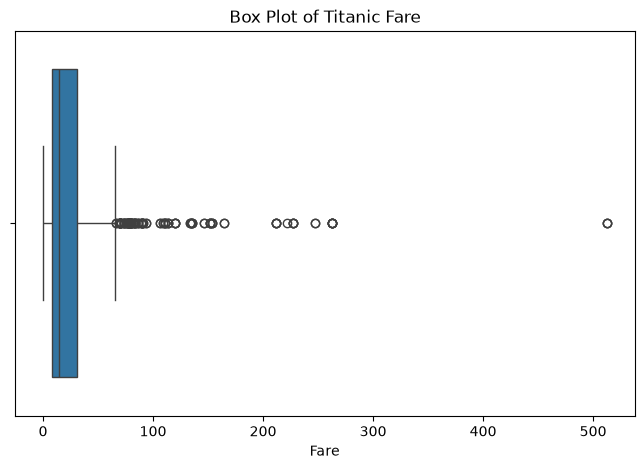

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Titanic Fare")
plt.xlabel("Fare")
plt.show()

## 7. Winsorization, Capping and Flooring

### Concept

Instead of removing extreme observations, we can limit their values to selected boundaries.

- **Capping:** Replace values above an upper limit with the upper limit.
- **Flooring:** Replace values below a lower limit with the lower limit.
- **Winsorization:** Limit extreme values at selected lower and upper percentiles.

### Example

For the Titanic `Fare` column, very high fares can be capped at the 99th percentile if the modelling objective requires reducing the influence of extreme values.

### Implementation

We will create a new capped version of `Fare`. The original column will not be modified.

### Output

The original and capped maximum values will be compared.

### Interpretation

Capping reduces the influence of extreme values while keeping the observations in the dataset.

### Insight

Capping can be safer than deletion when extreme observations may represent valid passengers.

### AI/ML Relevance

Capping can reduce the effect of extreme numerical values on algorithms that are sensitive to large differences in feature values.

In [9]:
upper_limit = df["Fare"].quantile(0.99)

df["Fare_Capped"] = df["Fare"].clip(upper=upper_limit)

print("Original Maximum Fare:", df["Fare"].max())
print("Capping Limit:", upper_limit)
print("Capped Maximum Fare:", df["Fare_Capped"].max())

Original Maximum Fare: 512.3292
Capping Limit: 249.00622000000035
Capped Maximum Fare: 249.00622000000035


## 8. Transformation

### Concept

A transformation changes the scale or distribution of a numerical feature. Log transformation is commonly used to reduce strong right skewness.

### Example

The Titanic `Fare` feature contains many lower values and a smaller number of very high values. A log transformation can reduce the effect of this right-skewed distribution.

### Implementation

We will create a log-transformed version of `Fare` using `log1p()`.

### Output

The transformed feature will be added as a new column.

### Interpretation

The transformation compresses large fare values more than smaller values.

### Insight

Transformation can be useful when extreme values are valid but their scale creates problems for analysis or modelling.

### AI/ML Relevance

A suitable transformation can make numerical features easier for some Machine Learning algorithms to work with and can reduce the influence of skewness.

In [10]:
df["Fare_Log"] = np.log1p(df["Fare"])

print(df[["Fare", "Fare_Log"]].head())

print("\nOriginal Fare Skewness:", df["Fare"].skew())
print("Log-Transformed Fare Skewness:", df["Fare_Log"].skew())

      Fare  Fare_Log
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765

Original Fare Skewness: 4.787316519674893
Log-Transformed Fare Skewness: 0.3949280095189306


## 9. Removing vs Retaining Outliers

### Concept

Outliers should not be automatically removed. The correct decision depends on whether the observation is an error or a valid extreme value.

### Example

In the Titanic dataset, a high `Fare` value can be a valid observation. Therefore, removing every high fare could remove useful information.

### Decision for this Dataset

For the `Fare` feature:

- The detected high values are not automatically considered errors.
- They may represent genuine ticket or passenger-related differences.
- Therefore, we should not remove them blindly.
- If a Machine Learning model is sensitive to extreme values, capping or transformation can be considered.
- The original values should be preserved until the final preprocessing decision is confirmed.

### Implementation

We will compare the original `Fare` feature with the capped and transformed versions.

### Output

The comparison shows how different treatment methods affect the same feature.

### Interpretation

The original data remains available, while alternative treatments can be evaluated separately.

### Insight

Outlier treatment should be based on data meaning, business context, and model requirements rather than only on a statistical rule.

### AI/ML Relevance

Removing valid extreme observations may introduce bias, while keeping problematic errors may negatively affect model performance. A balanced decision is therefore important.

In [11]:
comparison = df[["Fare", "Fare_Capped", "Fare_Log"]].describe()

display(comparison)

,Fare,Fare_Capped,Fare_Log
count,891.000000,891.000000,891.000000
mean,32.204208,31.224767,2.962246
std,49.693429,42.524125,0.969048
min,0.000000,0.000000,0.000000
25%,7.910400,7.910400,2.187218
50%,14.454200,14.454200,2.737881
75%,31.000000,31.000000,3.465736
max,512.329200,249.006220,6.240917


## 10. Preprocessing Decision Documentation

### Problem

The Titanic dataset contains potential outliers, particularly in numerical features such as `Fare`.

### Analysis

The IQR, Z-score, percentile methods, and box plot indicate that some fare values are unusually high. However, an extreme value does not necessarily mean that it is incorrect.

### Technique Selected

For analysis, IQR and Z-score were used to detect potential outliers. Capping and log transformation were demonstrated as possible treatment techniques.

### Reason

The outliers were not automatically removed because some extreme fare values may represent valid observations. Capping or transformation can reduce their influence while preserving the records.

### Implementation

A separate `Fare_Capped` column was created using the 99th percentile, and a `Fare_Log` column was created using log transformation. The original `Fare` column was preserved.

### Result

The original values remain unchanged, while alternative treated versions are available for comparison.

### Impact

Appropriate outlier treatment can improve model stability and reduce the influence of extreme values. However, removing valid observations could cause information loss and introduce bias.

### Final Decision

Outliers in this dataset should be investigated based on their meaning before applying a permanent treatment. No automatic deletion of outliers is performed in this notebook.

In [12]:
print("Original Fare column preserved:", "Fare" in df.columns)
print("Capped Fare column created:", "Fare_Capped" in df.columns)
print("Log-transformed Fare column created:", "Fare_Log" in df.columns)

print("\nFinal Fare Columns:")
display(df[["Fare", "Fare_Capped", "Fare_Log"]].head())

Original Fare column preserved: True
Capped Fare column created: True
Log-transformed Fare column created: True

Final Fare Columns:


,Fare,Fare_Capped,Fare_Log
0,7.2500,7.2500,2.110213
1,71.2833,71.2833,4.280593
2,7.9250,7.9250,2.188856
3,53.1000,53.1000,3.990834
4,8.0500,8.0500,2.202765


## Final Insight

The Titanic dataset contains extreme numerical observations, especially in the `Fare` feature. Statistical methods such as IQR, Z-score, and percentile analysis help identify these potential outliers.

However, the analysis shows that an outlier should not automatically be treated as an error. Since high fare values can be valid observations, removing them without investigation may result in information loss.

For future preprocessing, capping or transformation can be considered depending on the Machine Learning algorithm and modelling objective. The final treatment should be selected only after understanding the data and evaluating its effect on the model.